# 🤖 机器学习基础（Day 13）

> 今天把"理论解"和"数值解"真正对接起来：上午吃透**梯度下降**（一步步逼近最优解的优化算法），下午用 **PyTorch** 把**线性回归**和 **softmax 回归**各实现两遍（**从零实现** + **简洁实现**），彻底打通"训练一个模型"的完整链路。
>
> - **李宏毅《机器学习》第 10~17 讲**：梯度下降专题 —— 概念 / 代码 / 可视化 → BGD / SGD / MBGD → 学习率 / 特征缩放 / 动量
> - **李沐《动手学深度学习 V2》19.1~29.6**：线性回归从零实现 → 简洁实现 → softmax 回归从零实现 → 简洁实现
>
> 📺 视频链接：
> - 李宏毅机器学习：https://www.bilibili.com/video/BV1RnikBvE8m
> - 李沐动手学深度学习（PyTorch 版）：https://www.bilibili.com/video/BV1EY6FBwE8P

**学习安排：**

**上午（3h）—— 梯度下降实战（李宏毅 第 10~17 讲）**

1. 梯度下降基本概念与更新公式回顾
2. 三种梯度下降：BGD（批量）/ SGD（随机）/ MBGD（小批量）
3. 学习率 $\eta$ 的影响
4. 特征缩放（Feature Scaling）
5. 动量（Momentum）

**下午（3h）—— 用 PyTorch 实现线性回归与 softmax 回归（李沐 d2l 19.1~29.6）**

6. 线性回归：从零开始实现
7. 线性回归：PyTorch 简洁实现
8. softmax 回归：从零开始实现
9. softmax 回归：PyTorch 简洁实现

> ⚠️ **运行提示**：请从第一个代码单元格开始**按顺序**运行，后面的代码会用到前面定义好的变量与函数。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils import data

# 让 matplotlib 能正常显示中文（Windows 常见字体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False   # 让负号 "-" 正常显示

# 本笔记统一使用的颜色（与 Day11、Day12 风格一致）
蓝 = '#2b7bba'
橙 = '#e69f00'
灰 = '#999999'
红 = '#d62728'
绿 = '#2ca02c'

print("✓ 环境准备完成")
print("numpy", np.__version__, "| pandas", pd.__version__, "| torch", torch.__version__)

✓ 环境准备完成
numpy 2.3.5 | pandas 2.3.3 | torch 2.13.0+cpu


# 🎓 第一部分：梯度下降实战（李宏毅 第 10~17 讲）

> Day12 用**正规方程**"一步解出"线性回归的最优参数。但当特征很多、样本很大时，求逆矩阵 $(X^\top X)^{-1}$ 会变得很慢甚至不可行（$O(n^3)$）。这时就要请出**梯度下降**——不追求一步到位，而是**一步步逼近**最优解。
>
> 本部分对应李宏毅《机器学习》第 10~17 讲（梯度下降专题）：从"八元一次方程问题"出发，讲梯度下降的概念、代码实现与可视化，再到三种变体 BGD / SGD / MBGD，最后是学习率、特征缩放与动量。

## 1. 梯度下降：一步步滑向最低点

Day11 已经建立过直觉：**梯度下降就是"每次朝负梯度方向走一小步"**，反复迭代直到损失最小。

$$\theta \leftarrow \theta - \eta \cdot \nabla L(\theta)$$

- $\theta$：要优化的参数（如 $w, b$）；
- $\nabla L(\theta)$：损失 $L$ 对参数的**梯度**（指向损失上升最快的方向）；
- $\eta$：**学习率**，控制每一步走多大。

对一元线性回归 $y = wx + b$、损失 MSE，可以手推两个偏导：

$$\frac{\partial L}{\partial w} = \frac{2}{m}\sum_{i=1}^{m}(\hat y_i - y_i)\,x_i, \qquad \frac{\partial L}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}(\hat y_i - y_i)$$

> **停止条件**：理论上梯度 = 0 时到达最低点，但实际几乎不会正好等于 0，通常**人为设定迭代次数**或**误差阈值**就停止。

真实参数 w=3.0, b=1.0
梯度下降结果 w=3.041, b=0.948
损失从 6.95 一路降到 0.0733


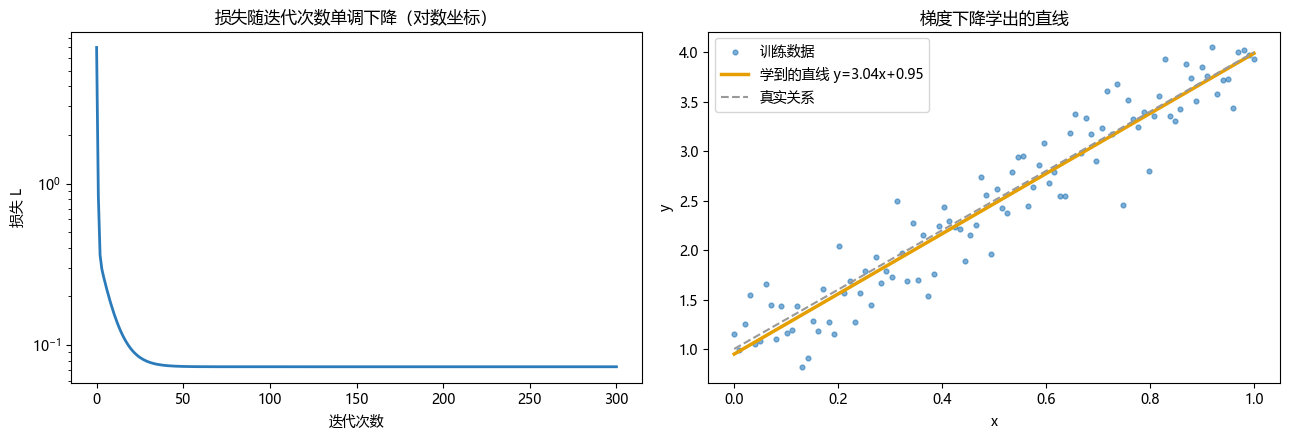

In [2]:
# ---- 从零实现梯度下降：求解一元线性回归 y = w·x + b ----
np.random.seed(42)
X = np.linspace(0, 1, 100)
真实w, 真实b = 3.0, 1.0
y = 真实w * X + 真实b + np.random.randn(100) * 0.3

def 模型(x, w, b):
    return w * x + b

def 损失(w, b):
    return np.mean((模型(X, w, b) - y) ** 2)

# ---- 梯度下降迭代 ----
w, b = 0.0, 0.0                     # 随便给个初始参数
学习率 = 0.5
轨迹 = [(w, b, 损失(w, b))]
for _ in range(300):
    y_hat = 模型(X, w, b)
    dw = np.mean(2 * (y_hat - y) * X)   # ∂L/∂w
    db = np.mean(2 * (y_hat - y))       # ∂L/∂b
    w -= 学习率 * dw                     # 朝负梯度方向走一步
    b -= 学习率 * db
    轨迹.append((w, b, 损失(w, b)))

print(f"真实参数 w={真实w}, b={真实b}")
print(f"梯度下降结果 w={w:.3f}, b={b:.3f}")
print(f"损失从 {轨迹[0][2]:.2f} 一路降到 {轨迹[-1][2]:.4f}")

# 左图：损失随迭代下降；右图：学出的直线
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot([t[2] for t in 轨迹], color=蓝, lw=2)
axes[0].set_xlabel('迭代次数'); axes[0].set_ylabel('损失 L')
axes[0].set_yscale('log')
axes[0].set_title('损失随迭代次数单调下降（对数坐标）')

axes[1].scatter(X, y, color=蓝, alpha=0.6, s=12, label='训练数据')
axes[1].plot(X, 模型(X, w, b), color=橙, lw=2.5, label=f'学到的直线 y={w:.2f}x+{b:.2f}')
axes[1].plot(X, 模型(X, 真实w, 真实b), color=灰, lw=1.5, ls='--', label='真实关系')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('梯度下降学出的直线')
axes[1].legend()
plt.tight_layout(); plt.show()

## 2. 三种梯度下降：BGD / SGD / MBGD

关键区别是**一次更新用多少条数据**：

| 方法 | 一次更新用多少数据 | 优点 | 缺点 |
| --- | --- | --- | --- |
| **BGD 批量梯度下降** | **全部**样本 | 梯度稳、方向准 | 每次都要扫全量数据，慢 |
| **SGD 随机梯度下降** | **1 条**样本 | 快、能逃离局部最小 | 梯度抖、方向乱 |
| **MBGD 小批量梯度下降** | **一小批**（如 32 / 64） | 折中：稳又快 | 要选 batch size |

> 实际深度学习里几乎都用 **MBGD**（PyTorch 里叫 mini-batch SGD）。注意：论文里的 "SGD" 经常泛指"小批量随机梯度下降"。

**更新公式对比**（$\hat y_i = w x_i + b$）：

- **BGD**：用全部 $m$ 条数据求平均梯度

  $$w \leftarrow w - \eta\,\frac{2}{m}\sum_{i=1}^{m}(\hat y_i - y_i)\,x_i$$

- **SGD**：每次随机抽 1 条 $i$ 更新

  $$w \leftarrow w - \eta \cdot 2(\hat y_i - y_i)\,x_i$$

- **MBGD**：每次随机抽一小批 $B$ 更新

  $$w \leftarrow w - \eta\,\frac{2}{|B|}\sum_{i \in B}(\hat y_i - y_i)\,x_i$$

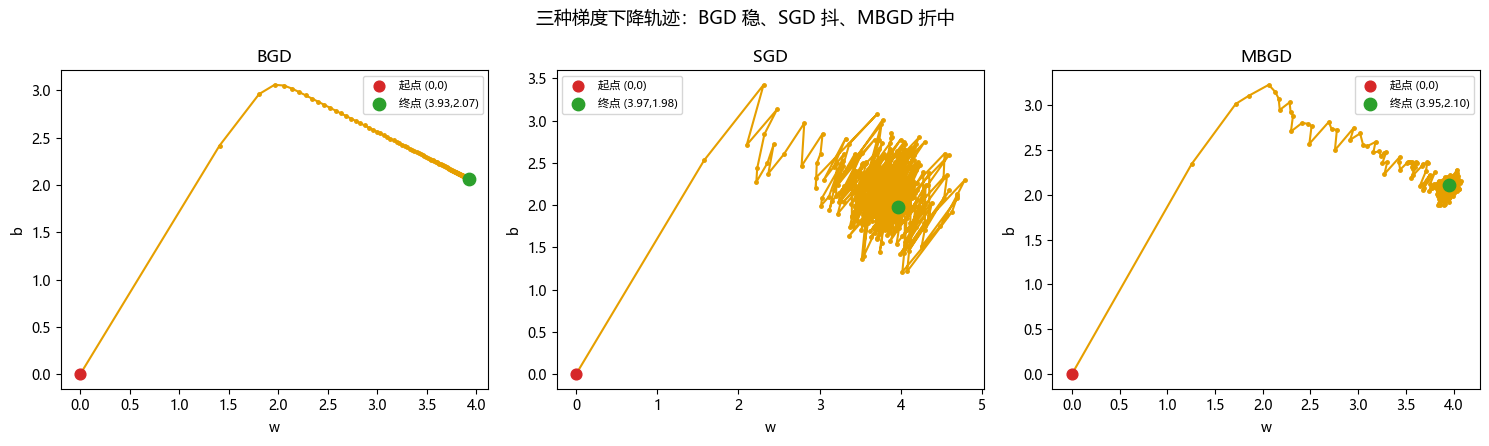

BGD: w=3.925, b=2.066  (真实 w=4, b=2)
SGD: w=3.693, b=2.241  (真实 w=4, b=2)
MBGD: w=3.853, b=1.981  (真实 w=4, b=2)


In [3]:
# ---- 三种梯度下降对比：BGD / SGD / MBGD ----
np.random.seed(0)
X = np.linspace(0, 1, 200)
y = 4.0 * X + 2.0 + np.random.randn(200) * 0.4

def 梯度(w, b, xi, yi):
    e = w * xi + b - yi
    return np.mean(2 * e * xi), np.mean(2 * e)

def 训练(xi, yi, 方法, 学习率=0.3, 迭代=500):
    w, b = 0.0, 0.0
    轨 = [(w, b)]
    for _ in range(迭代):
        if 方法 == 'BGD':
            dw, db = 梯度(w, b, xi, yi)                       # 全部数据
        elif 方法 == 'SGD':
            i = np.random.randint(len(xi))                     # 随机 1 条
            dw, db = 梯度(w, b, xi[i:i+1], yi[i:i+1])
        else:                                                  # MBGD
            idx = np.random.choice(len(xi), 16, replace=False) # 随机 16 条
            dw, db = 梯度(w, b, xi[idx], yi[idx])
        w -= 学习率 * dw
        b -= 学习率 * db
        轨.append((w, b))
    return np.array(轨)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, 方法 in zip(axes, ['BGD', 'SGD', 'MBGD']):
    轨 = 训练(X, y, 方法)
    ax.plot(轨[:, 0], 轨[:, 1], 'o-', color=橙, lw=1.5, ms=2.5)
    ax.scatter(*轨[0], color=红, s=60, zorder=5, label='起点 (0,0)')
    ax.scatter(*轨[-1], color=绿, s=80, zorder=5, label=f'终点 ({轨[-1,0]:.2f},{轨[-1,1]:.2f})')
    ax.set_title(方法)
    ax.set_xlabel('w'); ax.set_ylabel('b')
    ax.legend(fontsize=8)
plt.suptitle('三种梯度下降轨迹：BGD 稳、SGD 抖、MBGD 折中', fontsize=13)
plt.tight_layout(); plt.show()

# 数值对比：最终参数（真实 w=4, b=2）
for 方法 in ['BGD', 'SGD', 'MBGD']:
    轨 = 训练(X, y, 方法)
    print(f"{方法}: w={轨[-1,0]:.3f}, b={轨[-1,1]:.3f}  (真实 w=4, b=2)")

## 3. 学习率 $\eta$：步长是门学问

Day11 已经演示过：学习率太小"蚂蚁爬"、太大"青蛙乱跳"甚至发散。这里补充一个**实用经验**——在收敛过程中，损失往往会**先快后慢**，并可能在最优解附近**来回震荡**（尤其是 SGD / MBGD）。

| 学习率 | 现象 |
| --- | --- |
| **太小** | 收敛极慢，训练很久都到不了谷底 |
| **合适** | 平稳、快速地收敛 |
| **太大** | 震荡、甚至**发散**（损失越训越大） |

> 一句话：学习率是**最常调的超参数**。后面李宏毅还会讲"自适应学习率"（如 Adam），让每个参数有自己的学习率，就不用费劲手调了。

## 4. 特征缩放：让不同特征"站在同一起跑线"

如果特征的**量纲差别很大**（比如"面积 100 平米" vs "房间数 3 间"），损失曲面会变成一个**又窄又长的碗**：大尺度特征方向曲率很大、小尺度特征方向曲率很小。一个学习率顾得了这头就顾不了那头——**小尺度特征几乎学不到**。

**特征缩放**就是把所有特征缩放到相近的范围，让损失曲面变"圆"。两种常见方法：

- **Min-Max 归一化**：$x' = \frac{x - \min}{\max - \min}$，缩到 $[0, 1]$；
- **标准化（Z-Score）**：$x' = \frac{x - \mu}{\sigma}$，变成均值 0、标准差 1（**最常用**）。

不缩放：w1=1.00（真实 1）, w2=0.38（真实 10）, 最终损失 0.99
缩放后：w1=1.00, w2=9.92, 最终损失 0.10
→ 不缩放时小尺度特征 w2 几乎没学到，缩放后两个特征都学到了！


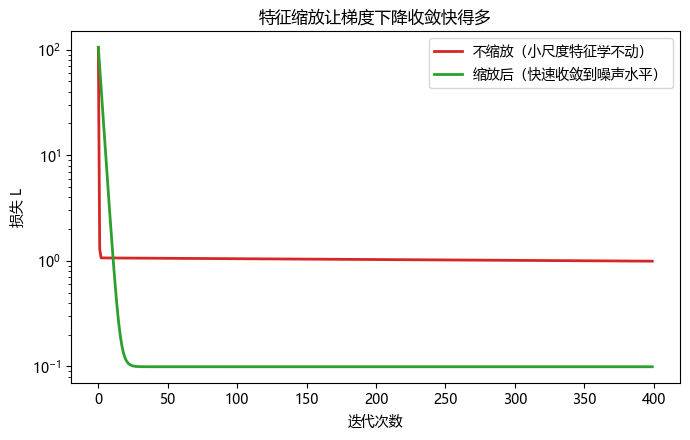

In [4]:
# ---- 特征缩放：为什么梯度下降需要它 ----
np.random.seed(3)
m = 500
x1 = np.random.randn(m) * 10.0     # 大尺度特征（标准差约 10）
x2 = np.random.randn(m) * 0.1      # 小尺度特征（标准差约 0.1）
y = 1.0 * x1 + 10.0 * x2 + np.random.randn(m) * 0.3   # 两个特征对 y 的贡献相当

def 训练(x1, x2, 学习率, 迭代):
    w1 = w2 = 0.0
    损失轨迹 = []
    for _ in range(迭代):
        e = w1*x1 + w2*x2 - y
        w1 -= 学习率 * np.mean(2*e*x1)
        w2 -= 学习率 * np.mean(2*e*x2)
        损失轨迹.append(np.mean(e**2))
    return 损失轨迹, w1, w2

# ① 不缩放：学习率被"大尺度"特征 x1 卡死，只能取很小（0.005）
L_raw, w1r, w2r = 训练(x1, x2, 学习率=0.005, 迭代=400)

# ② Z-Score 标准化：两个特征同一量级，可以放心用大学习率（0.1）
x1s = (x1 - x1.mean()) / x1.std()
x2s = (x2 - x2.mean()) / x2.std()
L_scl, w1s, w2s = 训练(x1s, x2s, 学习率=0.1, 迭代=400)

# 把缩放后学到的权重"还原"到原始量纲，方便和真实值比较
w1s_还原 = w1s / x1.std()
w2s_还原 = w2s / x2.std()

print(f"不缩放：w1={w1r:.2f}（真实 1）, w2={w2r:.2f}（真实 10）, 最终损失 {L_raw[-1]:.2f}")
print(f"缩放后：w1={w1s_还原:.2f}, w2={w2s_还原:.2f}, 最终损失 {L_scl[-1]:.2f}")
print("→ 不缩放时小尺度特征 w2 几乎没学到，缩放后两个特征都学到了！")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(L_raw, color=红, lw=2, label='不缩放（小尺度特征学不动）')
ax.plot(L_scl, color=绿, lw=2, label='缩放后（快速收敛到噪声水平）')
ax.set_xlabel('迭代次数'); ax.set_ylabel('损失 L')
ax.set_yscale('log')
ax.set_title('特征缩放让梯度下降收敛快得多')
ax.legend()
plt.tight_layout(); plt.show()

## 5. 动量 Momentum：给梯度下降"带上惯性"

普通梯度下降只看"当前梯度"。如果损失曲面有**平坦区**或**窄长谷**，梯度会很小或来回震荡，收敛很慢。**动量（Momentum）**给更新"带上惯性"，像球滚下山，能更快冲过平坦区、减少震荡：

$$v \leftarrow \gamma\, v + \eta\,\nabla L(\theta), \qquad \theta \leftarrow \theta - v$$

- $v$ 是"速度"（累积的历史梯度），$\gamma$ 是**动量系数**（通常取 0.9）；
- 更新时**参考了之前的方向**：震荡方向会被抵消，一致方向会被加速。

> Momentum 是 **Adam** 等现代优化器的基础，也是李宏毅后续讲"自适应学习率"的铺垫。

普通 GD 到 (1,1) 的距离：0.7574
动量 GD 到 (1,1) 的距离：0.0014


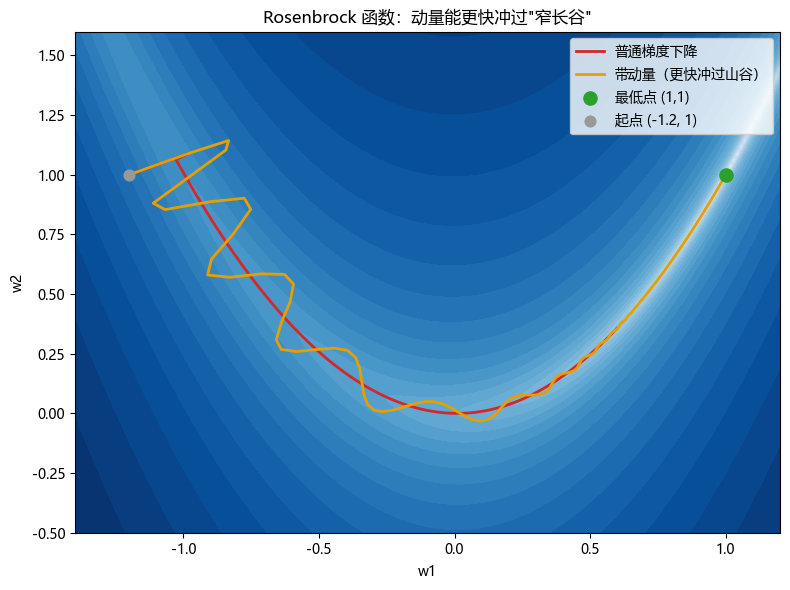

In [5]:
# ---- 动量 vs 普通梯度下降：谁更快冲过"窄长谷" ----
# 经典测试函数：Rosenbrock f(w1,w2) = (1-w1)² + 100(w2-w1²)²
# 最低点在 (1,1)，但损失曲面是一条又窄又弯的"山谷"，普通 GD 会来回震荡。
def rosenbrock(w1, w2):
    return (1 - w1)**2 + 100 * (w2 - w1**2)**2

def 梯度_rosen(w1, w2):
    dw1 = -2*(1 - w1) - 400*w1*(w2 - w1**2)
    dw2 = 200*(w2 - w1**2)
    return dw1, dw2

def 优化(方法, 学习率=1e-3, 迭代=1500):
    w1, w2 = -1.2, 1.0            # 经典起点
    v1 = v2 = 0.0
    轨 = [(w1, w2)]
    for _ in range(迭代):
        dw1, dw2 = 梯度_rosen(w1, w2)
        if 方法 == '动量':
            v1 = 0.9*v1 + 学习率*dw1      # γ = 0.9
            v2 = 0.9*v2 + 学习率*dw2
            w1 -= v1; w2 -= v2
        else:
            w1 -= 学习率*dw1; w2 -= 学习率*dw2
        轨.append((w1, w2))
    return np.array(轨)

轨_普通 = 优化('普通')
轨_动量 = 优化('动量')

print(f"普通 GD 到 (1,1) 的距离：{np.linalg.norm(轨_普通[-1] - np.array([1,1])):.4f}")
print(f"动量 GD 到 (1,1) 的距离：{np.linalg.norm(轨_动量[-1] - np.array([1,1])):.4f}")

W1, W2 = np.meshgrid(np.linspace(-1.4, 1.2, 200), np.linspace(-0.5, 1.6, 200))
Z = rosenbrock(W1, W2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(W1, W2, np.log10(Z + 1e-3), levels=30, cmap='Blues')
ax.plot(轨_普通[:, 0], 轨_普通[:, 1], '-', color=红, lw=2, label='普通梯度下降')
ax.plot(轨_动量[:, 0], 轨_动量[:, 1], '-', color=橙, lw=2, label='带动量（更快冲过山谷）')
ax.scatter([1], [1], color=绿, s=90, zorder=5, label='最低点 (1,1)')
ax.scatter(*轨_普通[0], color=灰, s=60, zorder=5, label='起点 (-1.2, 1)')
ax.set_xlabel('w1'); ax.set_ylabel('w2')
ax.set_title('Rosenbrock 函数：动量能更快冲过"窄长谷"')
ax.legend()
plt.tight_layout(); plt.show()

## 6. 本部分小结

| 概念 | 一句话直觉 |
| --- | --- |
| 梯度下降 | 每次朝负梯度方向走一小步，逼近最优解 |
| BGD / SGD / MBGD | 一次更新用全部 / 1 条 / 一小批数据 |
| 学习率 | 步长：太小慢、太大发散 |
| 特征缩放 | 把特征缩到同量级，让损失曲面变"圆"，收敛更快 |
| 动量 Momentum | 带惯性下坡，冲过平坦区、减少震荡 |

# 🧮 第二部分：用 PyTorch 实现线性回归与 softmax 回归（李沐 d2l 19.1~29.6）

> 第一部分用 numpy 手推了梯度下降；这一部分用 **PyTorch** 把"训练一个模型"的完整流程跑通，对应《动手学深度学习 V2》第三章"线性神经网络"：
> - **19.1 线性回归**：模型 / 损失 / 优化三大组件
> - **21.3 线性回归的从零开始实现**
> - **22.4 线性回归的简洁实现**
> - **24.1 softmax 回归**：多分类
> - **27.4 softmax 回归的从零开始实现**
> - **28.5 softmax 回归的简洁实现**
>
> 关键体会：**同一个模型，从零写和用 `torch.nn` 写，结果一致**——`nn` 只是把"从零实现"里的手工代码打包成了现成模块。

## 7. 线性回归：从零开始实现

线性回归的三大组件（对应 Day11 的"训练三步曲"）：

1. **模型**：$\hat y = Xw + b$，参数是权重 $w$ 和偏置 $b$；
2. **损失**：均方误差 $\ell = \frac{1}{2}(\hat y - y)^2$；
3. **优化**：小批量随机梯度下降（mini-batch SGD）。

先造一个带噪声的**合成数据**（因为真实世界拿不到"真实参数"，合成数据能让我们验证"学到的参数是否接近真实值"）：

$$y = Xw + b + \epsilon,\qquad \epsilon\sim\mathcal{N}(0, 0.01)$$

特征形状: torch.Size([1000, 2]) | 标签形状: torch.Size([1000, 1])
真实 w = [2.0, -3.4000000953674316] | 真实 b = 4.2


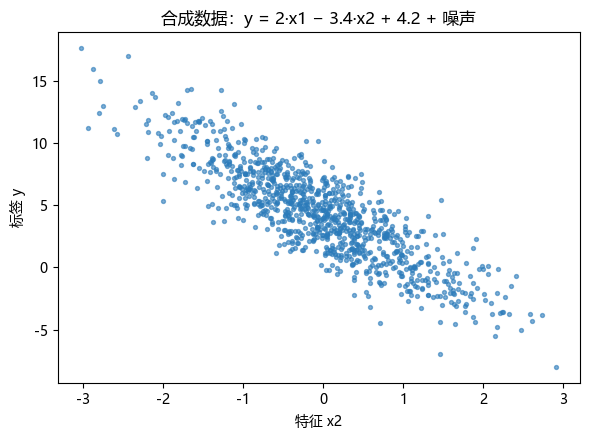

一批数据：X 形状 torch.Size([10, 2]) | y 形状 torch.Size([10, 1])


In [6]:
# ---- 合成数据集：y = X·w + b + 噪声 ----
def 合成数据(w, b, 样本数=1000):
    X = torch.normal(0, 1, (样本数, len(w)))
    y = X @ w + b                                    # shape (样本数,)
    y += torch.normal(0, 0.01, y.shape)              # 加噪声（形状与 y 一致）
    return X, y.reshape(-1, 1)

真实w = torch.tensor([2.0, -3.4])
真实b = 4.2
features, labels = 合成数据(真实w, 真实b)
print("特征形状:", features.shape, "| 标签形状:", labels.shape)
print("真实 w =", 真实w.tolist(), "| 真实 b =", 真实b)

# 画出第二个特征与标签的散点（能看到明显的线性关系）
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(features[:, 1].numpy(), labels.numpy(), color=蓝, s=8, alpha=0.6)
ax.set_xlabel('特征 x2'); ax.set_ylabel('标签 y')
ax.set_title('合成数据：y = 2·x1 − 3.4·x2 + 4.2 + 噪声')
plt.tight_layout(); plt.show()

# ---- 小批量数据迭代器 ----
def 数据迭代器(batch_size, X, y):
    num = len(X)
    indices = list(range(num))
    np.random.shuffle(indices)
    for i in range(0, num, batch_size):
        batch_idx = torch.tensor(indices[i: i + batch_size])
        yield X[batch_idx], y[batch_idx]

batch_size = 10
for Xb, yb in 数据迭代器(batch_size, features, labels):
    print("一批数据：X 形状", Xb.shape, "| y 形状", yb.shape)
    break

In [7]:
# ---- 初始化模型参数 / 定义模型、损失、优化器 ----
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def 线性模型(X, w, b):
    return X @ w + b

def 平方损失(y_hat, y):
    return (y_hat - y) ** 2 / 2      # 除 2 让求导更简洁

def sgd(参数, 学习率, batch_size):
    with torch.no_grad():
        for 参数i in 参数:
            参数i -= 学习率 * 参数i.grad / batch_size   # 求平均梯度
            参数i.grad.zero_()

# ---- 训练循环：前向 → 反向 → 更新 ----
学习率 = 0.03
轮数 = 3
for epoch in range(轮数):
    for Xb, yb in 数据迭代器(batch_size, features, labels):
        l = 平方损失(线性模型(Xb, w, b), yb)   # 前向：算损失
        l.sum().backward()                     # 反向：自动求梯度
        sgd([w, b], 学习率, batch_size)         # 更新参数
    with torch.no_grad():
        训练损失 = 平方损失(线性模型(features, w, b), labels).mean()
        print(f"epoch {epoch+1}, loss {训练损失.item():.6f}")

print("\n学到的 w =", [round(x, 3) for x in w.reshape(-1).tolist()], "| 真实 w = [2.0, -3.4]")
print("学到的 b =", round(b.item(), 3), "| 真实 b = 4.2")
print("→ 训练后参数几乎等于真实值！")

epoch 1, loss 0.040106
epoch 2, loss 0.000147


epoch 3, loss 0.000048

学到的 w = [2.0, -3.4] | 真实 w = [2.0, -3.4]
学到的 b = 4.199 | 真实 b = 4.2
→ 训练后参数几乎等于真实值！


## 8. 线性回归：PyTorch 简洁实现

从零实现里，我们要手动写"模型 / 损失 / 优化 / 数据迭代"。PyTorch 的 `nn` 和 `optim` 把这些都打包好了：

| 组件 | 从零实现 | 简洁实现 |
| --- | --- | --- |
| 模型 | 手写 `X @ w + b` | `nn.Linear(2, 1)` |
| 损失 | 手写平方损失 | `nn.MSELoss()` |
| 优化 | 手写 sgd | `optim.SGD(model.parameters(), lr)` |
| 数据 | 手写迭代器 | `DataLoader` + `TensorDataset` |

> 注意：`nn.MSELoss()` 默认**返回均值**，所以反向时不需要再除以 batch size。

In [8]:
# ---- 简洁实现：几行搭好 模型 + 损失 + 优化器 ----
def load_array(X, y, batch_size, is_train=True):
    dataset = data.TensorDataset(X, y)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

net = nn.Sequential(nn.Linear(2, 1))
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

data_iter = load_array(features, labels, batch_size)

轮数 = 3
for epoch in range(轮数):
    for Xb, yb in data_iter:
        l = loss(net(Xb), yb)          # 前向
        trainer.zero_grad()            # 清空梯度
        l.backward()                   # 反向
        trainer.step()                 # 更新
    l = loss(net(features), labels)
    print(f"epoch {epoch+1}, loss {l.item():.6f}")

w_hat = net[0].weight.data.reshape(-1).tolist()
b_hat = net[0].bias.data.item()
print("\n学到的 w =", [round(x, 3) for x in w_hat], "| 真实 w = [2.0, -3.4]")
print("学到的 b =", round(b_hat, 3), "| 真实 b = 4.2")
print("→ 与从零实现结果一致，但代码简洁得多！")

epoch 1, loss 0.000271
epoch 2, loss 0.000097
epoch 3, loss 0.000095

学到的 w = [2.0, -3.4] | 真实 w = [2.0, -3.4]
学到的 b = 4.199 | 真实 b = 4.2
→ 与从零实现结果一致，但代码简洁得多！


## 9. softmax 回归：多分类

线性回归输出一个**连续数值**；softmax 回归把线性输出**转成概率**，用来做**多分类**（输出 $K$ 个类别的概率，加起来 = 1）。

- **模型**：先算每个类别的"得分" $o_k = x\cdot w_k + b_k$，再用 **softmax** 归一化：

  $$\hat y_k = \frac{e^{o_k}}{\sum_j e^{o_j}}$$

- **损失**：**交叉熵**（衡量两个概率分布有多接近，$y_k$ 是 one-hot 真实标签）：

  $$L = -\sum_k y_k \log \hat y_k$$

> 交叉熵是**分类问题的标准损失函数**（Day11 提过）。softmax + 交叉熵搭配，能保证梯度形状干净、训练稳定。

X 形状: torch.Size([600, 2]) | y 形状: torch.Size([600]) | 类别数: 3


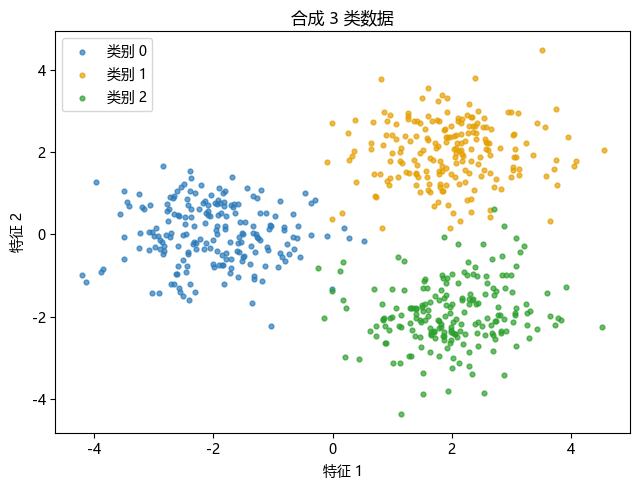

In [9]:
# ---- 合成 3 类数据（2 个特征，3 个类别）----
torch.manual_seed(0)
def 合成分类数据(样本数=600):
    中心 = torch.tensor([[-2.0, 0.0], [2.0, 2.0], [2.0, -2.0]])
    X = torch.zeros(样本数, 2)
    y = torch.zeros(样本数, dtype=torch.long)
    for i in range(样本数):
        类别 = i % 3
        X[i] = 中心[类别] + torch.normal(0, 0.8, (2,))
        y[i] = 类别
    return X, y

X, y = 合成分类数据(600)
print("X 形状:", X.shape, "| y 形状:", y.shape, "| 类别数:", len(torch.unique(y)))

# 可视化三类数据
fig, ax = plt.subplots(figsize=(6.5, 5))
for k in range(3):
    颜色 = [蓝, 橙, 绿][k]
    ax.scatter(X[y == k, 0].numpy(), X[y == k, 1].numpy(), color=颜色, s=12, alpha=0.7, label=f'类别 {k}')
ax.set_xlabel('特征 1'); ax.set_ylabel('特征 2')
ax.set_title('合成 3 类数据')
ax.legend()
plt.tight_layout(); plt.show()

In [10]:
# ---- 从零实现 softmax 与交叉熵 ----
def softmax(X):
    减去 = X - X.max(dim=1, keepdim=True).values   # 减最大值防数值溢出
    e = torch.exp(减去)
    return e / e.sum(dim=1, keepdim=True)

def 交叉熵(y_hat, y):
    # y_hat 是 softmax 后的概率 (n, K)，y 是类别标签 (n,)
    return -torch.log(y_hat[range(len(y_hat)), y])

# 检验 softmax：每行之和应为 1
p = softmax(torch.normal(0, 1, (2, 3)))
print("softmax 输出：\n", p)
print("每行概率之和：", p.sum(dim=1))

# ---- 初始化参数：输入 2 维 → 输出 3 类 ----
W = torch.normal(0, 0.01, size=(2, 3), requires_grad=True)
b = torch.zeros(3, requires_grad=True)

def 分类模型(X):
    return softmax(X @ W + b)

# ---- 训练（数据量小，这里用全批量梯度下降；工业上一般用 mini-batch）----
学习率 = 0.1
轮数 = 100
for epoch in range(轮数):
    l = 交叉熵(分类模型(X), y).mean()
    l.backward()
    with torch.no_grad():
        W -= 学习率 * W.grad
        b -= 学习率 * b.grad
        W.grad.zero_(); b.grad.zero_()
    if (epoch + 1) % 20 == 0:
        预测 = 分类模型(X).argmax(dim=1)
        准确率 = (预测 == y).float().mean().item()
        print(f"epoch {epoch+1:3d}, loss {l.item():.4f}, 准确率 {准确率:.3f}")

softmax 输出：
 tensor([[0.4169, 0.0626, 0.5205],
        [0.7539, 0.0844, 0.1617]])
每行概率之和： tensor([1., 1.])


epoch  20, loss 0.2269, 准确率 0.987
epoch  40, loss 0.1451, 准确率 0.988
epoch  60, loss 0.1143, 准确率 0.990
epoch  80, loss 0.0976, 准确率 0.988
epoch 100, loss 0.0870, 准确率 0.987


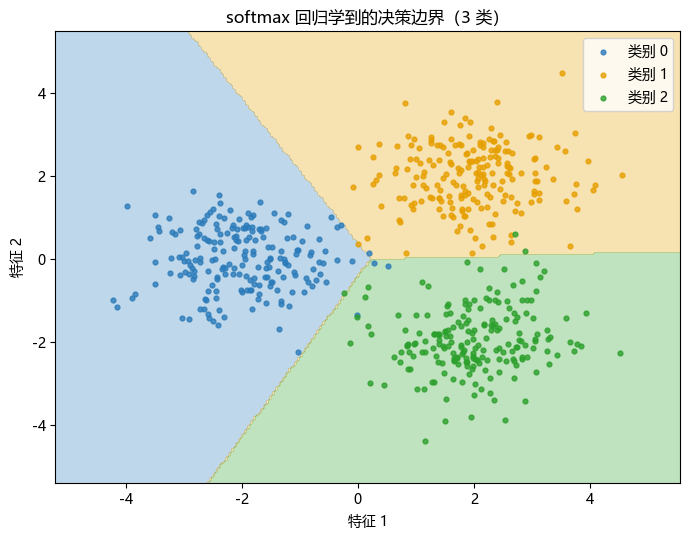

训练准确率：0.987


In [11]:
# ---- 画出学到的决策边界 ----
def 预测(X):
    return (X @ W.detach() + b.detach()).argmax(dim=1)

xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
yy = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
XX, YY = np.meshgrid(xx, yy)
网格点 = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)
Z = 预测(网格点).reshape(XX.shape).numpy()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(XX, YY, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=[蓝, 橙, 绿], alpha=0.3)
for k in range(3):
    ax.scatter(X[y == k, 0].numpy(), X[y == k, 1].numpy(), color=[蓝, 橙, 绿][k], s=12, alpha=0.8, label=f'类别 {k}')
ax.set_xlabel('特征 1'); ax.set_ylabel('特征 2')
ax.set_title('softmax 回归学到的决策边界（3 类）')
ax.legend()
plt.tight_layout(); plt.show()

准确率 = (预测(X) == y).float().mean().item()
print(f"训练准确率：{准确率:.3f}")

## 10. softmax 回归：PyTorch 简洁实现

和线性回归一样，`nn` 一行就能搭好模型。**关键点**：PyTorch 的 `nn.CrossEntropyLoss()` **已经内置了 softmax**，所以模型里只需输出"得分"（logits），**不要再手动套 softmax**，否则会重复算一遍、结果出错。

In [12]:
# ---- 简洁实现：nn.Linear + CrossEntropyLoss ----
net = nn.Sequential(nn.Linear(2, 3))       # 只输出"得分"，不再套 softmax
loss = nn.CrossEntropyLoss()               # 内部已含 softmax
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

dataset = data.TensorDataset(X, y)
data_iter = data.DataLoader(dataset, batch_size=64, shuffle=True)

for epoch in range(50):
    for Xb, yb in data_iter:
        l = loss(net(Xb), yb)
        trainer.zero_grad()
        l.backward()
        trainer.step()

预测 = net(X).argmax(dim=1)
准确率 = (预测 == y).float().mean().item()
print(f"简洁实现训练准确率：{准确率:.3f}（与从零实现一致）")

简洁实现训练准确率：0.990（与从零实现一致）


# 🎯 总结

今天把"训练模型"这条链路**从头到尾**打通了：

- **上午**（李宏毅 第 10~17 讲）：吃透**梯度下降**——三种变体 BGD / SGD / MBGD、学习率、特征缩放、动量，理解了"怎么一步步逼近最优解"。
- **下午**（李沐 d2l 19.1~29.6）：用 **PyTorch** 把**线性回归**和 **softmax 回归**各实现两遍——**从零实现**（理解原理）和**简洁实现**（用 `nn` / `optim`），并掌握了"模型 / 损失 / 优化器"三段式训练循环。

## 一句话记住今天

> **梯度下降 = 一步步逼近最优解的优化算法（BGD / SGD / MBGD + 学习率 + 特征缩放 + 动量）；用 PyTorch 训练模型 = 定义模型 → 定义损失 → 选优化器 → 循环"前向、反向、更新"，线性回归和 softmax 回归都逃不出这个框架。**

## 下一步

下一讲将进入**多层感知机（MLP）与深度学习**：堆叠隐藏层、引入非线性激活、处理过拟合（权重衰减、Dropout），并用 PyTorch 搭建真正的神经网络。